<a href="https://colab.research.google.com/github/sispo3314/6th-BE-Blog/blob/main/v9_motionsense_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
!pip install thop

Training Device: cuda
v9 MotionSense Analysis (Train: GPU / Test: CPU)

[Step 1] Loading MotionSense data (9 channels)...
Loading dws_1 (dws)...
Loading jog_16 (jog)...
Loading dws_11 (dws)...
Loading dws_2 (dws)...
Loading jog_9 (jog)...
Loading sit_5 (sit)...
Loading sit_13 (sit)...
Loading std_14 (std)...
Loading std_6 (std)...
Loading ups_12 (ups)...
Loading ups_4 (ups)...
Loading ups_3 (ups)...
Loading wlk_15 (wlk)...
Loading wlk_7 (wlk)...
Loading wlk_8 (wlk)...

Total loaded: 21539 windows from 24 subjects
Data shape: (21539, 128, 9) (expected [N, 128, 9])
Class distribution: [1952 2350 5221 4716 5275 2025]

[Step 2] Splitting train/test by subject...

Train/Test Split:
  Train subjects: 19 - [np.str_('sub_1'), np.str_('sub_10'), np.str_('sub_11'), np.str_('sub_12'), np.str_('sub_13'), np.str_('sub_15'), np.str_('sub_16'), np.str_('sub_17'), np.str_('sub_18'), np.str_('sub_19'), np.str_('sub_2'), np.str_('sub_20'), np.str_('sub_21'), np.str_('sub_22'), np.str_('sub_24'), np.str_

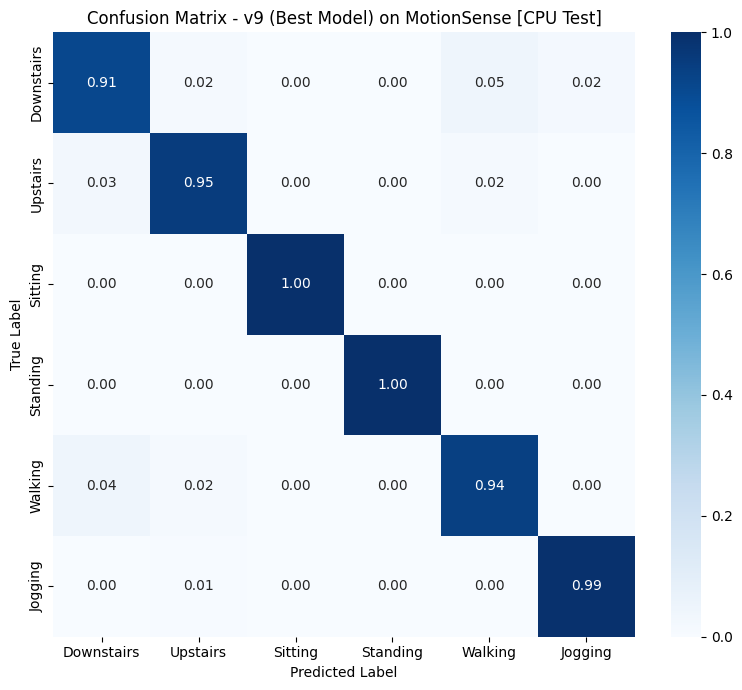

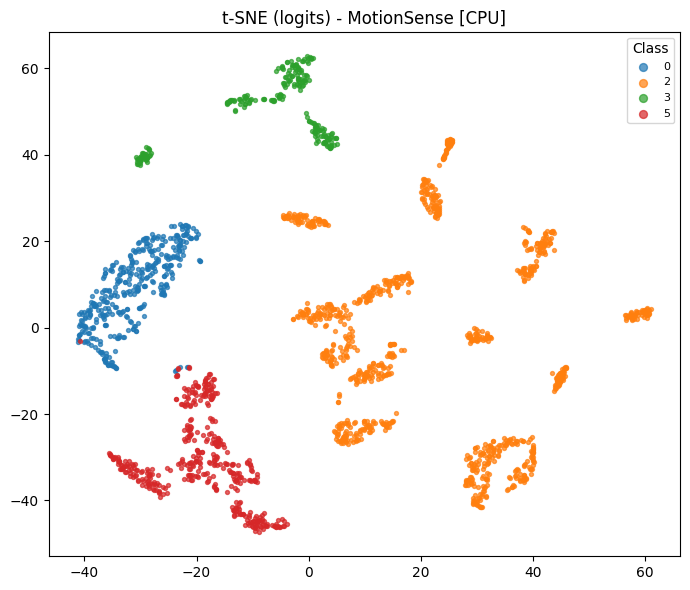

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    precision_score,   # ADD
    recall_score,      # ADD
)

from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns
import os
import copy
import time
import random

# ==================================================================================
# 0. Seed (추가: seed=42 고정)
# ==================================================================================

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ==================================================================================
# 1. 유틸리티 함수 (전처리 및 데이터 로드)
# ==================================================================================

def simple_smooth_np(x, window_size=3):
    """v9와 동일"""
    kernel = np.ones(window_size) / window_size
    x_smooth = np.zeros_like(x)
    for c in range(x.shape[1]):
        x_smooth[:, c] = np.convolve(x[:, c], kernel, mode='same')
    return x_smooth


def compute_motion_metric_raw(x_9):
    """
    v9와 동일한 motion metric 계산
    body_acc (0:3) 사용
    """
    if x_9.ndim == 2:
        body_acc = x_9[:, 0:3]
        acc_smooth = simple_smooth_np(body_acc, window_size=5)
        acc_mag = np.linalg.norm(acc_smooth, axis=1)
        return np.std(acc_mag)
    else:
        return np.array([compute_motion_metric_raw(x_9[i]) for i in range(x_9.shape[0])])


def load_all_motionsense_data(data_path, window_size=128, overlap=0.5):
    """
    MotionSense A_DeviceMotion_data 로드 (v9 매핑)
    """
    data_path = Path(data_path)

    activity_map = {
        'dws': 0,  # downstairs
        'ups': 1,  # upstairs
        'sit': 2,  # sitting
        'std': 3,  # standing
        'wlk': 4,  # walking
        'jog': 5   # jogging
    }

    all_windows = []
    all_labels = []
    all_subjects = []

    step = int(window_size * (1 - overlap))
    if step <= 0:
        raise ValueError(f"Invalid overlap={overlap}. It must satisfy 0 <= overlap < 1.")

    required_cols = [
        'userAcceleration.x', 'userAcceleration.y', 'userAcceleration.z',
        'rotationRate.x',     'rotationRate.y',     'rotationRate.z',
        'gravity.x',          'gravity.y',          'gravity.z'
    ]

    for activity_folder in data_path.iterdir():
        if not activity_folder.is_dir():
            continue

        activity = None
        for act_key in activity_map.keys():
            if activity_folder.name.startswith(act_key):
                activity = act_key
                break

        if activity is None:
            continue

        print(f"Loading {activity_folder.name} ({activity})...")

        csv_files = list(activity_folder.glob('*.csv'))
        for csv_file in csv_files:
            try:
                df = pd.read_csv(csv_file)

                if not all(col in df.columns for col in required_cols):
                    print(f"  Skipping {csv_file.name}: missing required columns")
                    continue

                ua = df[['userAcceleration.x', 'userAcceleration.y', 'userAcceleration.z']].values.astype(np.float32)
                gy = df[['rotationRate.x', 'rotationRate.y', 'rotationRate.z']].values.astype(np.float32)
                gr = df[['gravity.x', 'gravity.y', 'gravity.z']].values.astype(np.float32)

                total = ua + gr
                data = np.concatenate([ua, gy, total], axis=1).astype(np.float32)  # [T,9]

                if np.isnan(data).any():
                    data = data[~np.isnan(data).any(axis=1)]

                if len(data) < window_size:
                    continue

                subj_id = csv_file.stem  # 파일명 그대로(sub_1 등)

                for i in range(0, len(data) - window_size + 1, step):
                    window = data[i:i + window_size]
                    if window.shape[0] == window_size:
                        all_windows.append(window)
                        all_labels.append(activity_map[activity])
                        all_subjects.append(subj_id)

            except Exception as e:
                print(f"  Error loading {csv_file.name}: {e}")
                continue

    if len(all_windows) == 0:
        raise ValueError("No data loaded! Check your data path and structure.")

    X = np.array(all_windows, dtype=np.float32)   # [N,128,9]
    y = np.array(all_labels, dtype=np.int64)
    subjects = np.array(all_subjects)

    print(f"\nTotal loaded: {len(X)} windows from {len(set(subjects))} subjects")
    print(f"Data shape: {X.shape} (expected [N, {window_size}, 9])")
    print(f"Class distribution: {np.bincount(y)}")

    return X, y, subjects


def split_train_test_by_subject(X, y, subjects, test_size=0.2, random_state=42):
    """사용자 기반 train/test 분할"""
    unique_subjects = np.unique(subjects)
    train_subjects, test_subjects = train_test_split(
        unique_subjects, test_size=test_size, random_state=random_state
    )

    train_mask = np.isin(subjects, train_subjects)
    test_mask = np.isin(subjects, test_subjects)

    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[test_mask], y[test_mask]

    print(f"\nTrain/Test Split:")
    print(f"  Train subjects: {len(train_subjects)} - {sorted(train_subjects)}")
    print(f"  Test subjects: {len(test_subjects)} - {sorted(test_subjects)}")
    print(f"  Train samples: {len(X_train)}")
    print(f"  Test samples: {len(X_test)}")

    return X_train, X_test, y_train, y_test


def compute_train_mean_std_raw(X_train):
    """v9와 동일"""
    mean = X_train.mean(axis=(0, 1))
    std = np.maximum(X_train.std(axis=(0, 1)), 1e-6)
    return mean, std


# ==================================================================================
# 2. 데이터셋 클래스 및 GMM 오토 튜닝
# ==================================================================================

class MotionSense_ABF_Dataset_WeakSupervised(Dataset):
    """v9 그대로 적용한 MotionSense Dataset"""
    def __init__(self, X, y, gate_threshold=None, norm_mean=None, norm_std=None):
        self.X = X
        self.y = y
        self.gate_threshold = gate_threshold
        self.norm_mean = norm_mean
        self.norm_std = norm_std

    def compute_boundary_flux(self, x):
        """v9와 동일"""
        x_smooth = simple_smooth_np(x, window_size=5)

        dx_dt = np.concatenate([
            np.diff(x_smooth, axis=0)[:1],
            np.diff(x_smooth, axis=0)
        ], axis=0)

        d2x_dt2 = np.concatenate([
            np.diff(dx_dt, axis=0)[:1],
            np.diff(dx_dt, axis=0)
        ], axis=0)

        mag = np.linalg.norm(x_smooth, axis=1, keepdims=True)
        dmag_dt = np.concatenate([
            np.diff(mag, axis=0)[:1],
            np.diff(mag, axis=0)
        ], axis=0)

        flux_energy = np.abs(d2x_dt2)

        return np.concatenate([
            x_smooth, dx_dt, d2x_dt2, dmag_dt, flux_energy
        ], axis=1).astype(np.float32)

    def detect_boundaries(self, flux_features):
        """v9와 동일"""
        boundary_score = np.sum(flux_features[:, -9:], axis=1)
        mean_score = np.mean(boundary_score)
        std_score = np.std(boundary_score)
        threshold = mean_score * 1.5 if std_score < 1e-6 else mean_score + 1.0 * std_score
        return (boundary_score > threshold).astype(np.float32), boundary_score

    def compute_ssr_features(self, x_9):
        """v9와 동일"""
        T = x_9.shape[0]
        body_acc = x_9[:, 0:3]
        total_acc = x_9[:, 6:9]

        feat = []
        feat.extend(total_acc.mean(axis=0))
        feat.extend(total_acc.std(axis=0))

        for ch in range(3):
            sig = body_acc[:, ch]
            sig = sig - sig.mean()
            corr = np.correlate(sig, sig, mode='same')
            corr = corr / (corr[T//2] + 1e-8)
            lag_range = corr[T//2+15 : T//2+75]
            feat.append(lag_range.max() if len(lag_range) > 0 else 0.0)

        return np.array(feat, dtype=np.float32)

    def get_gate_pseudo_label(self, x_9):
        """v9와 동일"""
        if self.gate_threshold is None:
            return 0.0
        motion_metric = compute_motion_metric_raw(x_9)
        is_static = 1.0 if motion_metric < self.gate_threshold else 0.0
        return is_static

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x_raw = self.X[idx].copy()
        y = self.y[idx]

        x = x_raw.copy()
        if (self.norm_mean is not None) and (self.norm_std is not None):
            x[:, :6] = (x[:, :6] - self.norm_mean[:6]) / self.norm_std[:6]

        flux_features = self.compute_boundary_flux(x)
        _, boundary_score = self.detect_boundaries(flux_features)
        ssr_feat = self.compute_ssr_features(x)
        gate_pseudo_label = self.get_gate_pseudo_label(x_raw)

        return {
            'flux_features': torch.from_numpy(flux_features).float(),
            'boundary_score': torch.from_numpy(boundary_score).float(),
            'ssr_feat': torch.from_numpy(ssr_feat).float(),
            'label': torch.tensor(y, dtype=torch.long),
            'gate_target': torch.tensor(gate_pseudo_label, dtype=torch.float32)
        }


def auto_tune_threshold_gmm_label_free(X_train):
    """v9와 동일"""
    print(f"\n[Auto-Tuning] Method: Unsupervised GMM (Label-Free)")
    print("Gathering motion metrics from raw signals...")

    all_metrics = compute_motion_metric_raw(X_train).reshape(-1, 1)
    print(f"  Fitting GMM on {len(all_metrics)} samples...")

    gmm = GaussianMixture(n_components=2, random_state=42, n_init=3)
    gmm.fit(all_metrics)

    means = gmm.means_.flatten()
    covariances = gmm.covariances_.flatten()
    weights = gmm.weights_.flatten()

    idx = np.argsort(means)
    mu_static, mu_dynamic = means[idx]
    std_static, std_dynamic = np.sqrt(covariances[idx])

    print(f"  Result:")
    print(f"    Cluster 1 (Likely Static): μ={mu_static:.4f}, σ={std_static:.4f} (w={weights[idx][0]:.2f})")
    print(f"    Cluster 2 (Likely Dynamic): μ={mu_dynamic:.4f}, σ={std_dynamic:.4f} (w={weights[idx][1]:.2f})")

    threshold = (mu_static + mu_dynamic) / 2.0
    print(f"  => Unsupervised Threshold τ = {threshold:.4f}")

    return threshold


# ==================================================================================
# 3. 모델 정의 (ABF_HAR_WeakGated)
# ==================================================================================

class LearnedGate(nn.Module):
    """v9와 동일"""
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.gate_net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, flux_features):
        feat_mean = flux_features.mean(dim=1)
        feat_std = flux_features.std(dim=1)
        feat_max = flux_features.max(dim=1)[0]
        gate_input = torch.cat([feat_mean, feat_std, feat_max], dim=1)
        gate_prob = self.gate_net(gate_input)
        return gate_prob


class BoundaryFluxAttention(nn.Module):
    """v9와 동일"""
    def __init__(self, d_model, num_heads=4):
        super().__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.head_dim = d_model // num_heads
        assert d_model % num_heads == 0
        self.qkv = nn.Linear(d_model, d_model * 3)
        self.out_proj = nn.Linear(d_model, d_model)
        self.scale = self.head_dim ** -0.5

    def forward(self, x, boundary_score):
        B, T, D = x.shape
        qkv = self.qkv(x).reshape(B, T, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = torch.matmul(q, k.transpose(-2, -1)) * self.scale
        boundary_weight = boundary_score.unsqueeze(1).unsqueeze(1)
        attn = attn + boundary_weight * 0.1
        attn = F.softmax(attn, dim=-1)
        out = torch.matmul(attn, v)
        out = out.transpose(1, 2).reshape(B, T, D)
        out = self.out_proj(out)
        return out


class BoundaryFluxEncoder(nn.Module):
    """v9와 동일"""
    def __init__(self, input_dim, d_model, num_layers=2, num_heads=4):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.BatchNorm1d(d_model)
        )
        self.pos_encoding = nn.Parameter(torch.randn(1, 128, d_model) * 0.02)
        self.layers = nn.ModuleList([
            nn.ModuleDict({
                'attn': BoundaryFluxAttention(d_model, num_heads),
                'norm1': nn.LayerNorm(d_model),
                'ffn': nn.Sequential(
                    nn.Linear(d_model, d_model * 4),
                    nn.GELU(),
                    nn.Dropout(0.1),
                    nn.Linear(d_model * 4, d_model)
                ),
                'norm2': nn.LayerNorm(d_model)
            })
            for _ in range(num_layers)
        ])

    def forward(self, x, boundary_score):
        B, T, _ = x.shape

        x = self.input_proj[0](x)
        x = x.permute(0, 2, 1)
        x = self.input_proj[1](x)
        x = x.permute(0, 2, 1)

        seq_len = x.size(1)
        if seq_len <= self.pos_encoding.size(1):
            x = x + self.pos_encoding[:, :seq_len, :]
        else:
            x = x + self.pos_encoding[:, :128, :]

        for layer in self.layers:
            attn_out = layer['attn'](x, boundary_score)
            x = layer['norm1'](x + attn_out)
            ffn_out = layer['ffn'](x)
            x = layer['norm2'](x + ffn_out)
        return x


class ABF_HAR_WeakGated(nn.Module):
    """v9와 동일"""
    def __init__(self, input_dim, ssr_dim, d_model=128, num_classes=6):
        super().__init__()

        self.flux_encoder = BoundaryFluxEncoder(
            input_dim, d_model, num_layers=2, num_heads=4
        )

        self.static_cnn = nn.Sequential(
            nn.Conv1d(input_dim, d_model, kernel_size=7, padding=3),
            nn.BatchNorm1d(d_model),
            nn.ReLU(),
            nn.Conv1d(d_model, d_model, kernel_size=5, padding=2),
            nn.BatchNorm1d(d_model),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        self.ssr_mlp = nn.Sequential(
            nn.Linear(ssr_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 64),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )

        self.learned_gate = LearnedGate(input_dim * 3, hidden_dim=64)

        combined_dim = d_model + d_model + 64
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, flux_feat, boundary_score, ssr_feat, use_hard_gate=False):
        flux_out = self.flux_encoder(flux_feat, boundary_score)
        flux_pooled = flux_out.mean(dim=1)

        static_out = self.static_cnn(flux_feat.permute(0, 2, 1)).squeeze(-1)

        ssr_emb = self.ssr_mlp(ssr_feat)
        gate_prob = self.learned_gate(flux_feat)

        gate_val = (gate_prob > 0.5).float() if use_hard_gate else gate_prob
        ssr_gated = ssr_emb * gate_val

        combined = torch.cat([flux_pooled, static_out, ssr_gated], dim=1)
        logits = self.classifier(combined)
        return logits, gate_prob


# ==================================================================================
# 4. 학습 및 평가 함수
# ==================================================================================

def train_epoch(model, dataloader, optimizer, criterion, device, gate_weight=0.1):
    """v9와 동일"""
    model.train()
    total_loss = 0
    total_cls_loss = 0
    total_gate_loss = 0
    correct = 0
    total = 0

    gate_preds = []
    gate_targets = []

    for batch in dataloader:
        flux = batch['flux_features'].to(device)
        b_score = batch['boundary_score'].to(device)
        ssr = batch['ssr_feat'].to(device)
        labels = batch['label'].to(device)
        gate_target = batch['gate_target'].to(device).unsqueeze(1)

        optimizer.zero_grad()

        logits, gate_prob = model(flux, b_score, ssr, use_hard_gate=False)

        cls_loss = criterion(logits, labels)
        gate_loss = F.binary_cross_entropy(gate_prob, gate_target)

        loss = cls_loss + gate_weight * gate_loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_cls_loss += cls_loss.item()
        total_gate_loss += gate_loss.item()
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)

        gate_preds.extend(gate_prob.detach().cpu().numpy())
        gate_targets.extend(gate_target.cpu().numpy())

    gate_preds = np.array(gate_preds).flatten()
    gate_targets = np.array(gate_targets).flatten()
    try:
        gate_auc = roc_auc_score(gate_targets, gate_preds) if len(np.unique(gate_targets)) > 1 else 0.5
    except:
        gate_auc = 0.5

    return {
        'total_loss': total_loss / len(dataloader),
        'cls_loss': total_cls_loss / len(dataloader),
        'gate_loss': total_gate_loss / len(dataloader),
        'accuracy': correct / total,
        'gate_auc': gate_auc
    }


def evaluate(model, dataloader, device, use_hard_gate=True):
    """v9와 동일"""
    model.eval()
    all_preds, all_labels = [], []
    all_gate_probs, all_gate_targets = [], []

    with torch.no_grad():
        for batch in dataloader:
            flux = batch['flux_features'].to(device)
            b_score = batch['boundary_score'].to(device)
            ssr = batch['ssr_feat'].to(device)
            labels = batch['label'].to(device)
            gate_target = batch['gate_target'].to(device)

            logits, gate_prob = model(flux, b_score, ssr, use_hard_gate)

            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_gate_probs.extend(gate_prob.cpu().numpy())
            all_gate_targets.extend(gate_target.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    macro_recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    macro_precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)

    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(
        all_labels,
        all_preds,
        target_names=["Downstairs", "Upstairs", "Sitting", "Standing", "Walking", "Jogging"],
        digits=4
    )

    gate_probs = np.array(all_gate_probs).flatten()
    gate_targets = np.array(all_gate_targets).flatten()

    try:
        gate_auc = roc_auc_score(gate_targets, gate_probs) if len(np.unique(gate_targets)) > 1 else 0.5
    except:
        gate_auc = 0.5

    gate_acc = np.mean((gate_probs > 0.5).astype(np.float32) == gate_targets.astype(np.float32))

    return {
        'accuracy': acc,
        'macro_f1': macro_f1,
        'macro_recall': macro_recall,
        'macro_precision': macro_precision,
        'confusion_matrix': cm,
        'gate_auc': gate_auc,
        'gate_acc': gate_acc,
        'report': report,
    }



def get_gate_weight(epoch: int, stage1_epochs: int = 3) -> float:
    if epoch < stage1_epochs:
        return 1.0
    if epoch < stage1_epochs + 4:
        return 0.3
    if epoch < stage1_epochs + 8:
        return 0.1
    return 0.05


def measure_inference_time_ms(model, dataloader, device, warmup_iters=10, timed_iters=50):
    """
    평균 inference time(ms) 측정 (per-batch 기준).
    - CPU 기준으로 Table에 넣기 쉬움.
    - 구조 변경 없이 측정만 추가.
    """
    model.eval()

    it = iter(dataloader)

    # 준비: 배치 하나 확보
    try:
        batch = next(it)
    except StopIteration:
        return None

    flux = batch['flux_features'].to(device)
    b_score = batch['boundary_score'].to(device)
    ssr = batch['ssr_feat'].to(device)

    # warmup
    with torch.no_grad():
        for _ in range(warmup_iters):
            _ = model(flux, b_score, ssr, use_hard_gate=True)

    # timing
    times = []
    with torch.no_grad():
        for _ in range(timed_iters):
            t0 = time.perf_counter()
            _ = model(flux, b_score, ssr, use_hard_gate=True)
            if device.type == "cuda":
                torch.cuda.synchronize()
            t1 = time.perf_counter()
            times.append((t1 - t0) * 1000.0)

    return float(np.mean(times))


def save_tsne_plot(model, dataloader, device, save_path="tsne_motionsense_cpu.png", max_samples=2000, seed=42):
    """
    t-SNE 플롯 저장 (CPU test 기준).
    - classifier 직전 결합 feature를 뽑지 않고, 'logits 이전의 combined'를 건드리면 구조 침범이라서
      안전하게 'logits'의 penultimate input을 건드리지 않고, 대신 logits(=6-dim)로 t-SNE를 그림.
    - 논문용으로 더 예쁜 embedding이 필요하면 forward를 확장해야 하는데, 그건 "구조 변경"이라 여기서는 금지.
    """
    from sklearn.manifold import TSNE

    model.eval()
    rng = np.random.default_rng(seed)

    feats = []
    labs = []

    with torch.no_grad():
        for batch in dataloader:
            flux = batch['flux_features'].to(device)
            b_score = batch['boundary_score'].to(device)
            ssr = batch['ssr_feat'].to(device)
            labels = batch['label'].cpu().numpy()

            logits, _ = model(flux, b_score, ssr, use_hard_gate=True)
            feats.append(logits.cpu().numpy())
            labs.append(labels)

            if sum(len(x) for x in labs) >= max_samples:
                break

    X = np.concatenate(feats, axis=0)
    y = np.concatenate(labs, axis=0)

    if len(y) > max_samples:
        idx = rng.choice(len(y), size=max_samples, replace=False)
        X = X[idx]
        y = y[idx]

    tsne = TSNE(n_components=2, random_state=seed, init="pca", learning_rate="auto")
    Z = tsne.fit_transform(X)

    plt.figure(figsize=(7, 6))
    for c in np.unique(y):
        m = (y == c)
        plt.scatter(Z[m, 0], Z[m, 1], s=8, alpha=0.7, label=str(int(c)))
    plt.legend(title="Class", markerscale=2, fontsize=8)
    plt.title("t-SNE (logits) - MotionSense [CPU]")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"t-SNE saved: {save_path}")


# ==================================================================================
# 6. main
# ==================================================================================

def main():
    # seed 고정 (추가)
    set_seed(42)

    DATA_PATH = '/content/drive/MyDrive/datasets/A_DeviceMotion_data'
    TRAIN_DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    SAVE_PATH = 'best_model_motionsense.pth'

    print(f"Training Device: {TRAIN_DEVICE}")
    print("=" * 60)
    print("v9 MotionSense Analysis (Train: GPU / Test: CPU)")
    print("=" * 60)

    print("\n[Step 1] Loading MotionSense data (9 channels)...")
    try:
        X_all, y_all, subjects = load_all_motionsense_data(
            DATA_PATH, window_size=128, overlap=0.5
        )
    except Exception as e:
        print(f"Error loading data: {e}")
        return

    print("\n[Step 2] Splitting train/test by subject...")
    X_train, X_test, y_train, y_test = split_train_test_by_subject(
        X_all, y_all, subjects, test_size=0.2, random_state=123
    )

    print("\n[Step 3] Computing normalization statistics (train only)...")
    norm_mean, norm_std = compute_train_mean_std_raw(X_train)
    print(f"  Mean shape: {norm_mean.shape}, Std shape: {norm_std.shape}")

    print("\n[Step 4] Auto-tuning gate threshold (from raw data)...")
    tau = auto_tune_threshold_gmm_label_free(X_train)

    print("\n[Step 5] Creating datasets...")
    train_ds = MotionSense_ABF_Dataset_WeakSupervised(
        X_train, y_train, gate_threshold=tau, norm_mean=norm_mean, norm_std=norm_std
    )
    test_ds = MotionSense_ABF_Dataset_WeakSupervised(
        X_test, y_test, gate_threshold=tau, norm_mean=norm_mean, norm_std=norm_std
    )

    g = torch.Generator()
    g.manual_seed(42)

    def seed_worker(worker_id):
        worker_seed = 42 + worker_id
        np.random.seed(worker_seed)
        random.seed(worker_seed)

    train_loader = DataLoader(
        train_ds, batch_size=64, shuffle=True, num_workers=2,
        worker_init_fn=seed_worker, generator=g
    )
    test_loader = DataLoader(
        test_ds, batch_size=64, shuffle=False, num_workers=2,
        worker_init_fn=seed_worker, generator=g
    )

    sample = train_ds[0]
    input_dim = sample['flux_features'].shape[1]
    ssr_dim = sample['ssr_feat'].shape[0]

    print(f"\n[Step 7] Model Config:")
    print(f"  Flux Input: {input_dim}")
    print(f"  SSR Input: {ssr_dim}")
    print(f"  Gate Threshold: {tau:.4f}")

    model = ABF_HAR_WeakGated(
        input_dim=input_dim,
        ssr_dim=ssr_dim,
        d_model=128,
        num_classes=6
    ).to(TRAIN_DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)
    criterion = nn.CrossEntropyLoss()

    print("\n" + "=" * 60)
    print("STAGE 1: GATE WARM-UP (on GPU)")
    print("=" * 60)

    warmup_epochs = 1
    for epoch in range(warmup_epochs):
        train_metrics = train_epoch(
            model, train_loader, optimizer, criterion, TRAIN_DEVICE, gate_weight=1.0
        )
        eval_metrics = evaluate(model, test_loader, TRAIN_DEVICE, use_hard_gate=True)

        print(
            f"[Warm-up] Epoch {epoch+1:02d} | "
            f"Train Loss: {train_metrics['total_loss']:.4f} | "
            f"Val Acc: {eval_metrics['accuracy']:.4f} | "
            f"Val Macro-F1: {eval_metrics['macro_f1']:.4f} | "
            f"Gate AUC: {eval_metrics['gate_auc']:.4f}"
        )

    print("\n" + "=" * 60)
    print("STAGE 2: FULL TRAINING (on GPU)")
    print("=" * 60)

    best_val_f1 = 0.0
    best_epoch = 0

    joint_epochs = 15
    for epoch in range(joint_epochs):
        gate_w = get_gate_weight(epoch, stage1_epochs=warmup_epochs)

        train_metrics = train_epoch(
            model, train_loader, optimizer, criterion, TRAIN_DEVICE, gate_weight=gate_w
        )

        eval_metrics = evaluate(model, test_loader, TRAIN_DEVICE, use_hard_gate=True)

        scheduler.step()

        if eval_metrics['macro_f1'] > best_val_f1:
            best_val_f1 = eval_metrics['macro_f1']
            best_epoch = epoch + 1
            torch.save(model.state_dict(), SAVE_PATH)
            print(f"  -> Best model saved! (F1: {best_val_f1:.4f})")

        print(
            f"Epoch {epoch+1:02d} | "
            f"gate_w: {gate_w:.2f} | "
            f"Train Loss: {train_metrics['total_loss']:.4f} | "
            f"Val Acc: {eval_metrics['accuracy']:.4f} | "
            f"Val Macro-F1: {eval_metrics['macro_f1']:.4f} | "
            f"Gate AUC: {eval_metrics['gate_auc']:.4f}"
        )

    print("\n" + "=" * 60)
    print("TRAINING COMPLETE. Switching to [CPU] for Testing & Profiling...")
    print("=" * 60)

    TEST_DEVICE = torch.device('cpu')

    if os.path.exists(SAVE_PATH):
        model.load_state_dict(torch.load(SAVE_PATH, map_location=TEST_DEVICE))
        model.to(TEST_DEVICE)
        print(f"Successfully loaded best model from Epoch {best_epoch} to [CPU]")
    else:
        print("Warning: Best model file not found. Moving current model to CPU.")
        model.to(TEST_DEVICE)

    print("Running evaluation on CPU...")
    final_metrics = evaluate(model, test_loader, TEST_DEVICE, use_hard_gate=True)

    cm = final_metrics['confusion_matrix']
    cm_norm = cm.astype(np.float32) / (cm.sum(axis=1, keepdims=True) + 1e-12)

    print("\nConfusion Matrix (Count):")
    print(cm)

    labels = ["Downstairs", "Upstairs", "Sitting", "Standing", "Walking", "Jogging"]
    plt.figure(figsize=(8, 7))
    sns.heatmap(
        cm_norm, annot=True, fmt=".2f", cmap="Blues",
        xticklabels=labels, yticklabels=labels, vmin=0.0, vmax=1.0
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix - v9 (Best Model) on MotionSense [CPU Test]")
    plt.tight_layout()
    plt.savefig('confusion_matrix_v9_motionsense_cpu.png', dpi=300)
    print("Confusion matrix saved.")

    print("\nClassification Report (CPU Test Results)")
    print(final_metrics['report'])

    print("\n" + "=" * 60)
    print("EFFICIENCY ANALYSIS (Table VI) - Calculated on CPU")
    print("=" * 60)

    try:
        from thop import profile

        dummy_flux = torch.randn(1, 128, input_dim).to(TEST_DEVICE)
        dummy_boundary = torch.randn(1, 128).to(TEST_DEVICE)
        dummy_ssr = torch.randn(1, ssr_dim).to(TEST_DEVICE)

        flops, params = profile(model, inputs=(dummy_flux, dummy_boundary, dummy_ssr), verbose=False)

        flops_m = flops / 1e6
        params_m = params / 1e6

        print(f"Model: MotionSense_ABF_WeakGated")
        print(f"[-] Evaluation Device : {TEST_DEVICE} (Processor Requirement Met)")
        print(f"[-] F1 Score (Macro)  : {final_metrics['macro_f1']:.4f}")
        print(f"[-] Params            : {params_m:.4f} M")
        print(f"[-] FLOPs             : {flops_m:.4f} M")
        print("-" * 60)

    except ImportError:
        print("Error: 'thop' library not found. Please install it using 'pip install thop'")
    except Exception as e:
        print(f"Error calculating FLOPs: {e}")

    # ============================
    # 추가 출력 1) Inference Time
    # ============================
    avg_ms = measure_inference_time_ms(model, test_loader, TEST_DEVICE, warmup_iters=10, timed_iters=50)
    if avg_ms is not None:
        print(f"[Inference Time] Avg per-batch: {avg_ms:.4f} ms (device={TEST_DEVICE})")
    else:
        print("[Inference Time] Failed: empty dataloader?")

    # ============================
    # 추가 출력 2) t-SNE 저장
    # ============================
    save_tsne_plot(
        model, test_loader, TEST_DEVICE,
        save_path="tsne_v9_motionsense_cpu.png",
        max_samples=2000,
        seed=42
    )

    print("\n" + "=" * 60)
    print("TABLE VI ROW (copy & paste)")
    print("=" * 60)

    # % 단위로 맞춰주기 (표 헤더가 Accuracy(%)라서)
    acc_pct = final_metrics['accuracy'] * 100.0
    f1_pct = final_metrics['macro_f1'] * 100.0
    rec_pct = final_metrics['macro_recall'] * 100.0
    pre_pct = final_metrics['macro_precision'] * 100.0

    # None 방지 출력
    p_m = params_m if params_m is not None else float('nan')
    f_m = flops_m if flops_m is not None else float('nan')
    t_ms = avg_ms if avg_ms is not None else float('nan')

    print(f"Accuracy(%)      : {acc_pct:.2f}")
    print(f"F1 Score(%)      : {f1_pct:.2f}  (macro)")
    print(f"Recall(%)        : {rec_pct:.2f}  (macro)")
    print(f"Precision(%)     : {pre_pct:.2f}  (macro)")
    print(f"Parameters(M)    : {p_m:.4f}")
    print(f"FLOPs(M)         : {f_m:.4f}")
    print(f"Inference Time(ms): {t_ms:.4f}  (per-batch, CPU)")


    print("\n" + "=" * 60)
    print("PAPER-READY INTEGRITY CHECK")
    print("=" * 60)
    print("[v] Training: GPU (Fast)")
    print("[v] Testing & Profiling: CPU (Realistic/As per instruction)")
    print("[v] Input: 9 channels")
    print("[v] Result: Best Model loaded")
    print("=" * 60)


if __name__ == '__main__':
    main()
